# SVM — Support Vector Machine

In [ ]:
The Story First 📖


Imagine two groups of students:
⭐ = Pass students
❌ = Fail students

Plot them on a graph:



marks
10|  ⭐  ⭐  ⭐
 8|    ⭐  ⭐
 6|  ❌    ⭐
 4|❌  ❌
 2|  ❌  ❌
  |____________
    2  4  6  8  hours

Question:
Draw a line separating ⭐ and ❌!

You can draw MANY lines!
SVM finds the BEST line!

In [ ]:

What Makes SVM Special — The Margin!


Many lines can separate the data!
But which one is BEST?

SVM finds the line with
MAXIMUM MARGIN between classes!

        ⭐  ⭐  ⭐
    ⭐  ⭐         ← Support Vectors
  - - - - - - - -  ← Decision Boundary
    ❌  ❌         ← Support Vectors
        ❌  ❌  ❌

↑margin↑   ↑margin↑

Wider margin = better generalization
= better on new data! ✅

In [ ]:
Key Terms:

Decision Boundary:
→ the line/curve separating classes
→ SVM finds BEST boundary!

Support Vectors:
→ data points closest to boundary
→ these points DEFINE the boundary!
→ if you remove other points,
   boundary stays same!
→ only support vectors matter!

Margin:
→ distance between boundary
  and nearest points of each class
→ SVM maximizes this! ✅

In [ ]:
Linear vs Non-Linear Data:

Linear data:          Non-linear data:
⭐⭐⭐ | ❌❌❌        ⭐⭐❌⭐⭐
⭐⭐  | ❌❌          ❌⭐⭐⭐❌
straight line works!  straight line fails!
                      need curved boundary!

Solution for non-linear → KERNEL TRICK! 🔥

In [ ]:
Kernel Trick — Most Important Concept!

Non-linear data in 2D:
can't separate with straight line!

Kernel trick:
→ transforms data to HIGHER dimension
→ data becomes linearly separable!
→ draw straight line in higher dimension
→ looks curved in original dimension!

Simple analogy:
Mix red and blue balls on a table (2D)
Can't separate with straight line!

Lift the table (go to 3D)
Now you can separate with a flat plane!
Kernel does exactly this! 🔥

# Types of Kernels:

"linear"  → straight line boundary
            use when data is linearly separable

"rbf"     → Radial Basis Function
            curved boundary ✅ (default, most used!)
            use for most real world data!

"poly"    → polynomial boundary
            curved but different shape

"sigmoid" → S-shaped boundary
            less common

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)

# BIG dataset — Disease Prediction
np.random.seed(42)
n = 300   # 300 patients!

data = {
    "age"            : np.random.randint(20, 70, n),
    "bmi"            : np.random.uniform(18, 40, n).round(1),
    "blood_pressure" : np.random.randint(60, 140, n),
    "cholesterol"    : np.random.randint(150, 300, n),
    "blood_sugar"    : np.random.uniform(70, 200, n).round(1),
    "heart_rate"     : np.random.randint(60, 100, n),
    "exercise_hours" : np.random.uniform(0, 10, n).round(1),
    "sleep_hours"    : np.random.uniform(4, 10, n).round(1),
    "stress_level"   : np.random.randint(1, 10, n),
    "smoking"        : np.random.randint(0, 2, n),
    "alcohol"        : np.random.randint(0, 2, n),
    "family_history" : np.random.randint(0, 2, n),
}

# target → has disease or not
disease = (
    (data["age"] > 45)               &
    (data["blood_pressure"] > 100)   |
    (data["cholesterol"] > 240)      &
    (data["blood_sugar"] > 140)      |
    (data["smoking"] == 1)           &
    (data["family_history"] == 1)
).astype(int)

data["disease"] = disease
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nDisease Distribution:")
print(df["disease"].value_counts())

Dataset Shape: (300, 13)

Disease Distribution:
disease
1    151
0    149
Name: count, dtype: int64


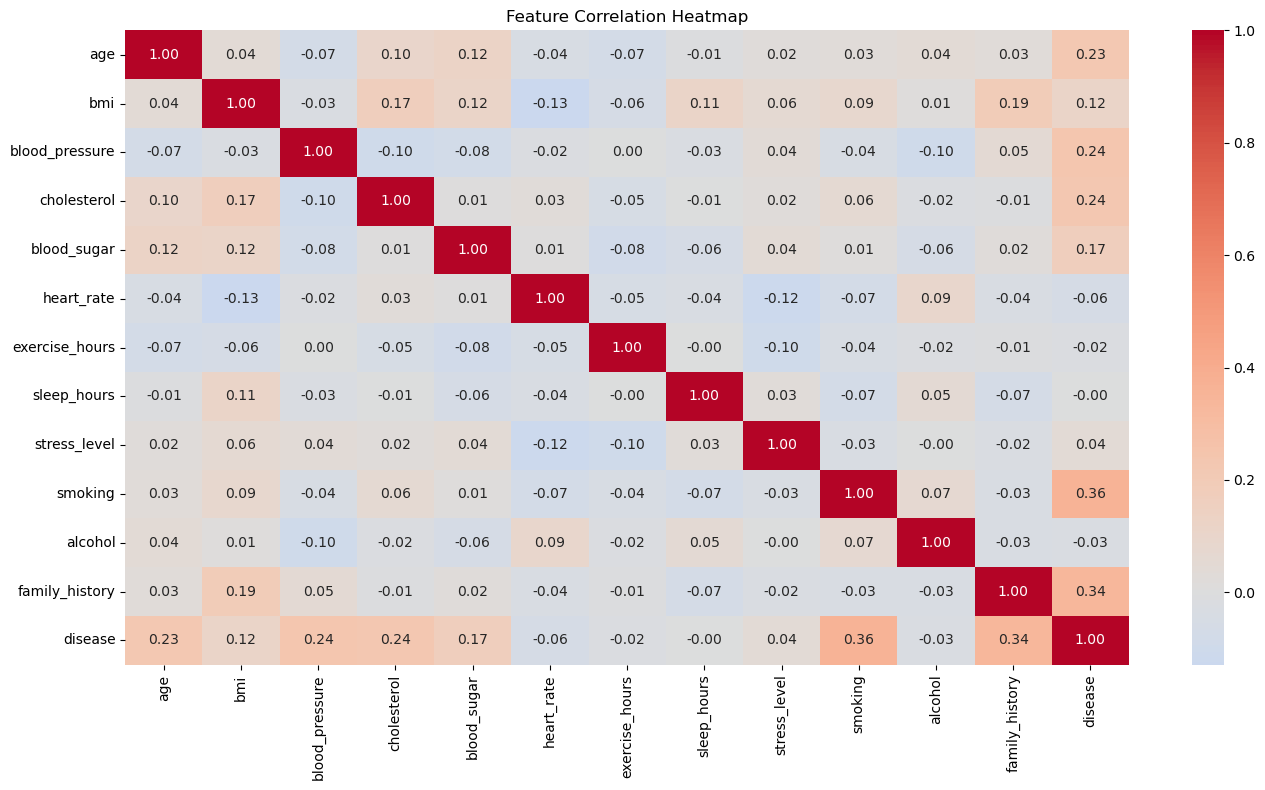

In [3]:
# EDA:

# correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Model Building:

In [4]:
X= df.drop("disease", axis = 1)
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling the data 
scaler= StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# svm model
model = SVC(
    kernel="rbf",# type of boundary
    C=1.0,# regularization
    gamma="scale",# kernel coefficient
    probability=True, # enable predict_proba
    random_state=42
)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
y_prob= model.predict_proba(X_test_scaled)

# check overfitting 
train_acc = accuracy_score(y_train,model.predict(X_train_scaled))
test_acc = accuracy_score(y_test,y_pred)


print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy :", round(test_acc, 4))
print("Difference    :", round(train_acc-test_acc, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Train Accuracy: 0.9667
Test Accuracy : 0.8
Difference    : 0.1667

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        27
           1       0.86      0.76      0.81        33

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60



# Parameters Explained 

In [ ]:
kernel="rbf":

        most important parameter!

        "linear"  → straight line (simple data)
        "rbf"     → curved boundary ✅ (default, use this!)
        "poly"    → polynomial curve
        "sigmoid" → S-shaped curve

        Always try rbf first!
        If not good → try others!
        C=1.0 — Regularization:
        Controls how strict boundary is

        High C (C=100):
        → tries to classify every point correctly
        → narrow margin
        → might overfit! ❌

        Low C (C=0.01):
        → allows some misclassifications
        → wider margin
        → might underfit! ❌

C=1.0 → balanced ✅ (default)

        Simple analogy:
        High C = strict teacher (no mistakes allowed!)
        Low C  = lenient teacher (some mistakes ok!)
        gamma="scale":
        controls influence of each training point

        "scale"  → 1/(n_features × X.var()) ✅ default
        "auto"   → 1/n_features

        High gamma → each point has small influence
                → complex boundary → overfit ❌

        Low gamma  → each point has large influence
           → smooth boundary → underfit ❌

"scale" works for most cases! ✅
probability=True:
False → model.predict() only (faster)
True  → model.predict_proba() enabled
        (gives probabilities like other models)

Always set True if you need probabilities! ✅

# Trying Different Kernels:

    kernel  train_acc  test_acc  difference
0   linear      0.854     0.733       0.121
1      rbf      0.967     0.800       0.167
2     poly      0.946     0.700       0.246
3  sigmoid      0.787     0.683       0.104


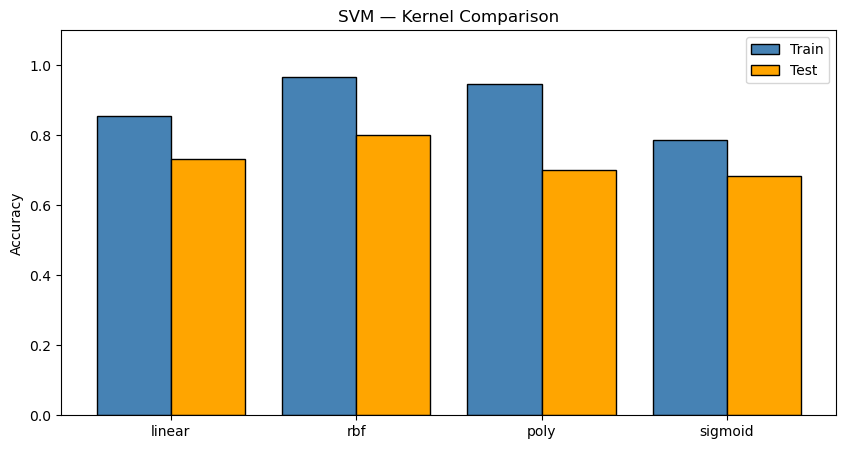

In [5]:
kernels = ["linear", "rbf", "poly", "sigmoid"]
results = []

for k in kernels:
    svm = SVC(kernel=k,
              probability=True,
              random_state=42)
    svm.fit(X_train_scaled, y_train)

    train_a = accuracy_score(y_train,
              svm.predict(X_train_scaled))
    test_a  = accuracy_score(y_test,
              svm.predict(X_test_scaled))

    results.append({
        "kernel"      : k,
        "train_acc"   : round(train_a, 3),
        "test_acc"    : round(test_a, 3),
        "difference"  : round(train_a-test_a, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

# plot
plt.figure(figsize=(10, 5))
x = range(len(kernels))
plt.bar([i-0.2 for i in x], results_df["train_acc"],
        width=0.4, label="Train",
        color="steelblue", edgecolor="black")
plt.bar([i+0.2 for i in x], results_df["test_acc"],
        width=0.4, label="Test",
        color="orange", edgecolor="black")
plt.xticks(x, kernels)
plt.title("SVM — Kernel Comparison")
plt.ylabel("Accuracy")
plt.legend()
plt.ylim([0, 1.1])
plt.show()

# Trying Different C values:

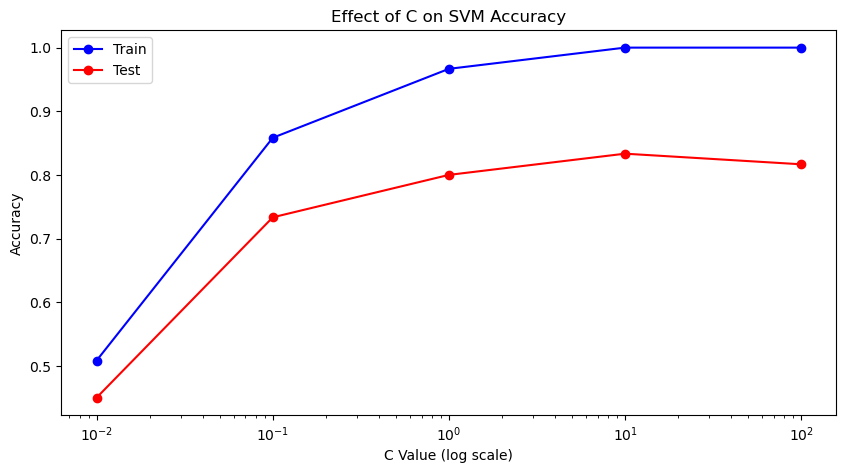

In [6]:
c_values   = [0.01, 0.1, 1, 10, 100]
train_accs = []
test_accs  = []

for c in c_values:
    svm = SVC(kernel="rbf", C=c,
              random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_accs.append(accuracy_score(y_train,
                      svm.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test,
                     svm.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(c_values, train_accs,
         label="Train", color="blue",
         marker="o")
plt.plot(c_values, test_accs,
         label="Test", color="red",
         marker="o")
plt.xscale("log")
plt.xlabel("C Value (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM Accuracy")
plt.legend()
plt.show()

# Visualization — 4 Plots:

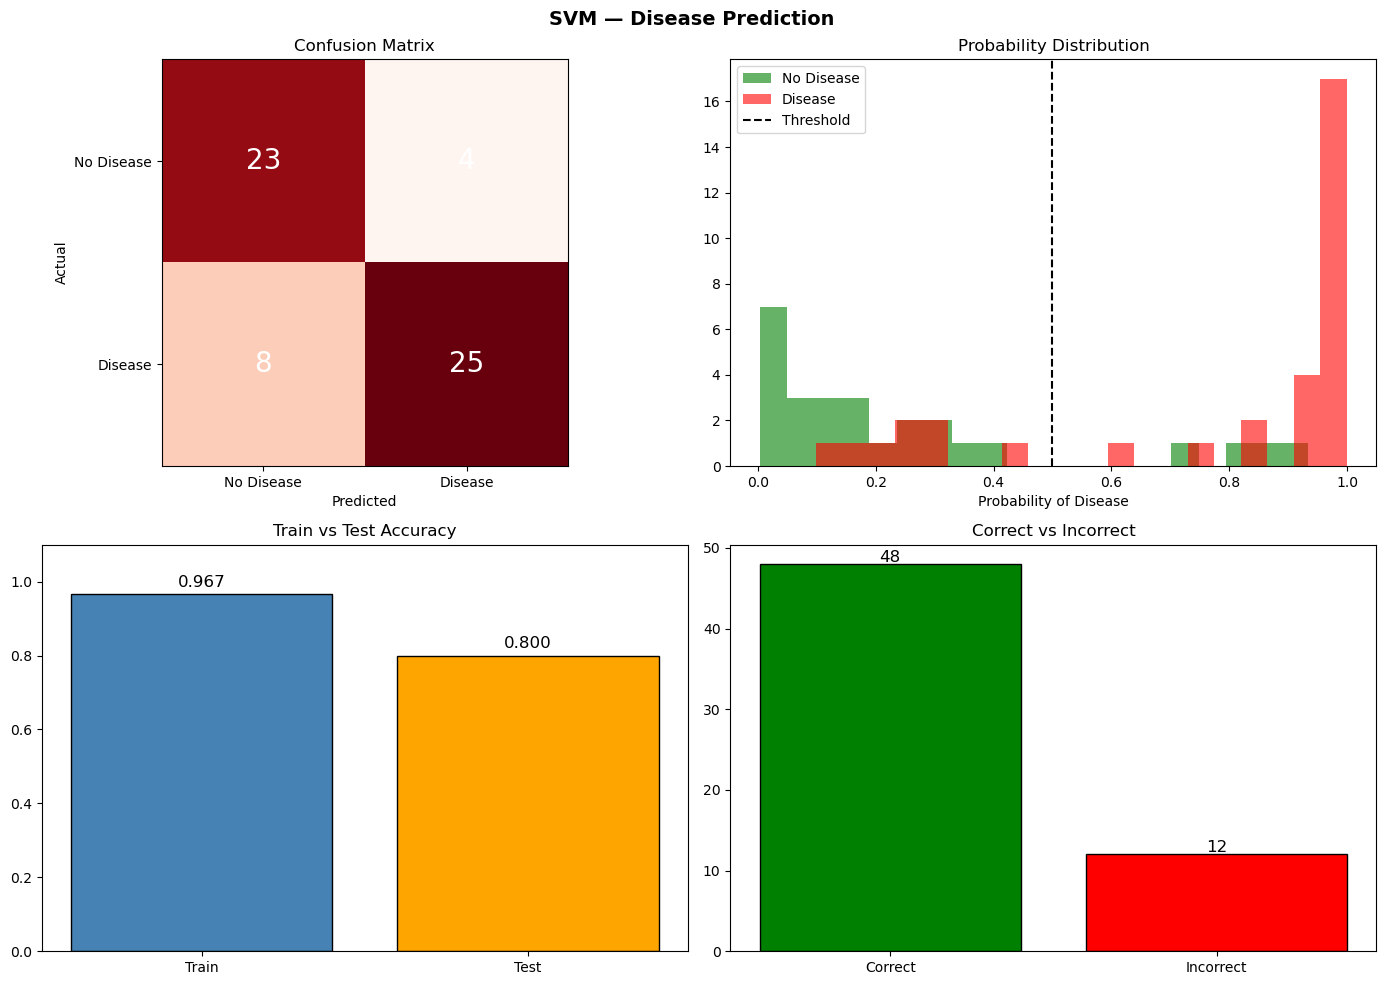

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
axes[0,0].imshow(cm, cmap="Reds")
axes[0,0].set_title("Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")
axes[0,0].set_xticks([0,1])
axes[0,0].set_yticks([0,1])
axes[0,0].set_xticklabels(["No Disease","Disease"])
axes[0,0].set_yticklabels(["No Disease","Disease"])
for i in range(2):
    for j in range(2):
        axes[0,0].text(j, i, cm[i,j],
                      ha="center", va="center",
                      color="white", fontsize=20)

# Plot 2 — Probability Distribution
axes[0,1].hist(y_prob[:,1][y_test==0],
               bins=20, alpha=0.6,
               color="green",
               label="No Disease")
axes[0,1].hist(y_prob[:,1][y_test==1],
               bins=20, alpha=0.6,
               color="red",
               label="Disease")
axes[0,1].axvline(x=0.5, color="black",
                  linestyle="--",
                  label="Threshold")
axes[0,1].set_title("Probability Distribution")
axes[0,1].set_xlabel("Probability of Disease")
axes[0,1].legend()

# Plot 3 — Train vs Test Accuracy
axes[1,0].bar(["Train", "Test"],
              [train_acc, test_acc],
              color=["steelblue","orange"],
              edgecolor="black")
axes[1,0].set_title("Train vs Test Accuracy")
axes[1,0].set_ylim([0, 1.1])
for i, v in enumerate([train_acc, test_acc]):
    axes[1,0].text(i, v+0.02,
                   f"{v:.3f}",
                   ha="center", fontsize=12)

# Plot 4 — Correct vs Incorrect
correct   = (y_test.values==y_pred).sum()
incorrect = (y_test.values!=y_pred).sum()
axes[1,1].bar(["Correct","Incorrect"],
              [correct, incorrect],
              color=["green","red"],
              edgecolor="black")
axes[1,1].set_title("Correct vs Incorrect")
for i, v in enumerate([correct, incorrect]):
    axes[1,1].text(i, v+0.3, str(v),
                   ha="center", fontsize=12)

plt.suptitle("SVM — Disease Prediction",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()